# DeepAFS: single-example strawberry fruit phenotyping (segmentation, linear descriptors, pseudolandmarks)

**Paper:** Zingaretti L. M., Monfort A., Pérez-Enciso M. (2021).
*Automatic Fruit Morphology Phenome and Genetic Analysis: An Application in the Octoploid Strawberry.*
Plant Phenomics 2021:9812910. DOI [10.34133/2021/9812910](https://doi.org/10.34133/2021/9812910) (PMC8139333, CC BY 4.0; a 2022 corrigendum exists).

**Author code:** `lauzingaretti/DeepAFS` @ commit `f8c348da6a73cf30a25f5a31a99d2df3e927b654` (GPL-3.0), files `Src/load_image.py`, `Src/scanIm.py`, `Src/linearDesc.py`, `Src/landmarks_gen.py`, `requirements.txt`.

**Scope of this notebook (partial demonstration):** segment **one** example fruit photograph
(`Examples/DSC_0385.JPG`) with the author's threshold pipeline, extract the fruit object,
compute the paper's **linear shape descriptors and CIELAB external color** (paper §2.2–2.4),
and compute **50 contour pseudolandmarks** plus **4th-order elliptical Fourier descriptors**
(paper §2.5/§2.6, flow phases 1–5). This is one worked example — it does **not** reproduce
dataset-level results, the genetic (BGLR) branch, or the autoencoder/VAE branches, which require
the unpublished 508-image dataset and proprietary pedigree.

**実行内容（日本語）:** 論文の DeepAFS パイプラインのうち、例題画像 1 枚
（`Examples/DSC_0385.JPG`）を対象に、閾値セグメンテーション → 果実オブジェクト抽出 →
線形形質（面積・周囲長・円形度・solidity・楕円比・25/50/75% 高さ幅・CIELAB 色）→
輪郭 50 擬似ランドマークと 4 次楕円フーリエ記述子の計算までを再現します。
遺伝解析・VAE 分岐は非公開データが必要なため対象外です。

**Execution status:** executed end-to-end on a fresh Google Colab **CPU** runtime
(no GPU needed: classical OpenCV/scikit-image processing, no neural network in this scope).

**Runtime to select:** `Runtime → Change runtime type → CPU` (default). Nothing here uses GPU.


## 1. Environment setup

The author's `requirements.txt` pins a 2020 scientific stack (numpy 1.19 etc.) that no longer
builds on Colab's Python. This notebook keeps the **author's algorithm code verbatim** and runs it
on Colab's current stack; the only extra installs are the small pure-Python packages not
preinstalled (`pyefd` for elliptical Fourier descriptors, `imutils` and `pytesseract` imported by
the author modules). The `pytesseract` *binary* is not required because label OCR is skipped
(`label=False`); the package is only imported at module top level.

**（日本語）** 著者コードはそのまま使用し、不足パッケージ（`pyefd`、`imutils`、`pytesseract`）
のみ追加インストールします。OCR は使用しないため tesseract バイナリは不要です。

In [ ]:
import sys, subprocess
for pkg in ["pyefd", "imutils", "pytesseract"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
import numpy, cv2, skimage, sklearn, scipy, pandas, matplotlib, PIL, pyefd, imutils
print("numpy", numpy.__version__)
print("opencv", cv2.__version__)
print("scikit-image", skimage.__version__)
print("scikit-learn", sklearn.__version__)
print("pyefd", pyefd.__version__ if hasattr(pyefd, "__version__") else "installed")
print("python", sys.version)

numpy 2.1.3
opencv 4.14.0
scikit-image 0.25.2
scikit-learn 1.6.1
pyefd installed
python 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


## 2. Compatibility shims (documented adaptations)

Two minimal, behavior-preserving adaptations are required to run the author's 2020-era code on a
2026 stack; they do **not** change any scientific operation:

1. `numpy.int` / `numpy.float` were removed in numpy ≥ 1.24; the author code calls `np.int(...)`
   (e.g. `Src/linearDesc.py` lines 86, 120, 186–196; `Src/landmarks_gen.py` line 165). We restore
   the aliases before importing the author modules.
2. `Src/scanIm.py`, `Src/linearDesc.py` and `Src/landmarks_gen.py` contain a vestigial top-level
   `import utils` that is **never used** in the executed path (the only `utils.`-looking hit is
   `imutils.rotate` at `scanIm.py:151`). We provide an empty stub module instead of installing the
   unrelated PyPI `utils` package.

**（日本語）** numpy の新バージョンで削除された `np.int` を復活させ、著者コード内の未使用の
`import utils` を空スタブで置き換えるのみで、科学的な処理自体は一切変更していません。

In [ ]:
import numpy as np
if not hasattr(np, "int"):
    np.int = int  # author code calls np.int(...) (removed in numpy>=1.24)
if not hasattr(np, "float"):
    np.float = float
# stub for the vestigial `import utils` in the author modules (never called)
import pathlib
pathlib.Path("/content/utils.py").write_text("")

0

**Creates the target directory.** `%%writefile` does not create intermediate directories, so the
next cells write the author's four `Src/` modules **byte-for-byte** from
`lauzingaretti/DeepAFS` @ `f8c348d` into `/content/Src/`, plus the package `__init__.py`.
Nothing in these files is edited; every algorithmic parameter below is the author's.

**（日本語）** 著者の `Src/` モジュール群を一切変更せず `/content/Src/` に書き込みます。

In [ ]:
import os
os.makedirs("/content/Src", exist_ok=True)
print("ready:", os.path.isdir("/content/Src"))

ready: True


**Writes `Src/load_image.py` verbatim:** class `load_image` (file reading,
histogram, and `agis()` threshold segmentation with the author's median-threshold + morphology
defaults, and `acis()` k-means color segmentation).
**（日本語）** 著者の画像読み込み・`agis()` セグメンテーション関数をそのまま書き込みます。

In [ ]:
%%writefile /content/Src/load_image.py
"""
Function to load and segment image using a thresholding method
"""

# requiriments

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFilter
import pytesseract
from pytesseract import image_to_string
import imutils
import glob



class load_image(object):
    """
    This class read image data into memory.
    """
    def __init__(self, fileName,Gray=False):
        self.fileName = fileName
        self.Gray =Gray
        self.img = cv2.imread(fileName)
        if Gray is True:
            self.img = cv2.cvtColor(self.img, cv2.COLOR_BGR2GRAY)
        self.shape=self.img.shape



    def __iter__(self):
        return self

    def histo(self):
        '''
        function to plot image histogram

        '''
        im = self.img
        if (im.shape[2]==3):
            im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
        hist,bins = np.histogram(im.ravel(),256,[0,256])
        plt.hist(im.ravel(),256,[0,256]); plt.show()



    def agis(self, kernelsize=3, threshold="Adap", ud=10 ,dilate=True,erode=True) :
        '''
        file name: path to img
        histogram: can you see the img hist?
        kernelsize: to medianBlur filtering (Default=3)
        threshold: method to img thresholding OTSU,BIN, Adapt,  Gaussian, i.e. authomatic, manual, automatic use of hist info, adaptative, gaussian
        ud: only works if threshold==BIN, a user defined number between  0 255 to define  the threshold value
        dilate: True or False
        erode: True or False
        '''
        threshold = threshold.lower()
        if threshold in ["adap","bin","otsu","gaussian"] is False:
            threshold="adap"
            print("warning, threshold should be one of adap,adap2,bin,otsu,gaussian")
        im = self.img
        if (im.shape[2]==3):
            im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
        if kernelsize>0:
            blur = cv2.medianBlur(im,kernelsize,0)
        if kernelsize==0:
            blur = im
        if threshold=="otsu":
            x=(np.median(im))
            x= x.astype(int)
            if x < 255/2:
                ret3,th3 = cv2.threshold(blur,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
            else:
                ret3,th3 = cv2.threshold(blur,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

            kernel = np.ones((16,16), np.uint8)

            th3 = cv2.morphologyEx(th3, cv2.MORPH_OPEN,kernel)
            if dilate is True:
                th3 = cv2.dilate(th3, None, iterations=4)
            if erode is True:
                th3 = cv2.erode(th3, None, iterations=8)

        if threshold=="bin":
            print("remember to select proper lower limit for binary thresholding, the histogram information is helpful ")
            x=(np.median(im))
            x= x.astype(int)
            if x < 255/2:
                th3= cv2.threshold(blur,ud,255,cv2.THRESH_BINARY)[1]
            else:
                th3= cv2.threshold(blur,ud,255,cv2.THRESH_BINARY_INV)[1]

            ret3=ud

            kernel = np.ones((16,16), np.uint8)

            th3 = cv2.morphologyEx(th3, cv2.MORPH_OPEN,kernel)

            if dilate is True:
                th3 = cv2.dilate(th3, None, iterations=4)
            if erode is True:
                th3 = cv2.erode(th3, None, iterations=8)

        if threshold=="adap":
            x=(np.median(im))
            x= x.astype(int)
            if x < 255/2:
                ret3,th3= cv2.threshold(blur,x,255,cv2.THRESH_BINARY)
            else:
                ret3,th3= cv2.threshold(blur,x,255,cv2.THRESH_BINARY_INV)
            kernel = np.ones((16,16), np.uint8)

            th3 = cv2.morphologyEx(th3, cv2.MORPH_OPEN,kernel)

            #ret3=x
            if dilate is True:
                th3 = cv2.dilate(th3, None, iterations=4)
            if erode is True:
                th3 = cv2.erode(th3, None, iterations=8)
        if threshold=="gaussian":
            x=(np.median(im))
            x= x.astype(int)
            if x < 255/2:
                th3 = cv2.adaptiveThreshold(blur,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,15,2)
            else:
                th3 = cv2.adaptiveThreshold(blur,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,15,2)
            kernel = np.ones((16,16), np.uint8)

            th3 = cv2.morphologyEx(th3, cv2.MORPH_OPEN,kernel)
            ret3=0
            if dilate is True:
                th3 = cv2.dilate(th3, None, iterations=4)
            if erode is True:
                th3 = cv2.erode(th3, None, iterations=8)




        self.thr=ret3
        self.mask=th3
        return(self)



    def acis(self, criteria="k-means", k=3,n_iter=10) :
        '''
        file name: path to img
        criteria: k-means (This is the only criteria right now)
        k: number of clusters
        n_iter number of iterations
        '''
        im = self.img
        if (im.shape[2]==1):
            im = cv2.cvtColor(im, cv2.COLOR_GRAY2RGB)
        pixel_values = im.reshape((-1, 3))
        pixel_values = np.float32(pixel_values)
        stop_criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
        centroid_initialization_strategy = cv2.KMEANS_RANDOM_CENTERS

        _, labels, centers = cv2.kmeans(pixel_values,
                                    k,
                                    None,
                                    stop_criteria,
                                    n_iter,
                                    centroid_initialization_strategy)

        centers = np.uint8(centers)
        segmented_data = centers[labels.flatten()]

        # Debemos reestructurar el arreglo de datos segmentados con las dimensiones de la imagen original.
        segmented_image = segmented_data.reshape(im.shape)

        mask_1=[]
        for cluster in np.unique(labels):
            mask= np.zeros((im.shape[0],im.shape[1]),dtype="uint8")
            La=labels.reshape(im.shape[0],im.shape[1])
            mask[La== cluster] = 255
            mask_1.append(mask)
        self.km=segmented_image
        self.mask=mask_1
        return(self)


Writing /content/Src/load_image.py


**Writes `Src/scanIm.py` verbatim:** class `imgObjects` with
`ExtractObjects()` — contour filtering (≥100 px, ratio 0.2–5), square canvas padding.
**（日本語）** 果実オブジェクト抽出関数 `ExtractObjects()` をそのまま書き込みます。

In [ ]:
%%writefile /content/Src/scanIm.py
# requiriments
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pytesseract
from pytesseract import image_to_string
import imutils
import utils
from PIL import Image, ImageDraw, ImageFilter
from .load_image import load_image
from scipy.stats import norm
from sklearn.neighbors import KernelDensity


#import glob --> I don't need this package

#####################
class imgObjects(load_image):
#####################
    """ This class calculates linear descriptors from a threshold image """
    #th3 from class load_image
    #min_expected_ratio betweeen objects to looking for
    #max_expected_ratio betweeen objects to looking for

    def __init__(self):
        # Invoca al constructor de clase load_image
        return(self)

    def ExtractObjects(self,min_expected_ratio=1, max_expected_ratio=2,output_size=None,write_output=True,output_path=None,output_name=None,label=False,expected_char="IP|LlC-0123456789"):
        """
        self an object from load_image class
        min_expected_ratio: minimum approximate ratio between height and width from fruits/leaves/ objects into the image (1 by default).
        Note that this is only necessary if there are others objects into the image
        max_expected_ratio: maximum approximate ratio between height and width from fruits/leaves/ objects into the image (2 by default).
        output_size: selected size (square) to the output files. If None, the size is extracted from the maximum contours.
        write_output: Would you like to save the extracted images? Default is True.
        output_path: path where the output should be saved. If none, the image would be saved in the main directory.
        output_name: the label for the output name. If none, the label is just "File".
        label: if label is True, the software try to read  automatically the label from the image.  Default is False.
        expected_char: some of char expected into the label, it helps to increase the pytesseract precision. For instance, if all the labels are in the format "Img-xxx",
        being xxx a numeric expression expected_char would be "|Img-0123456789".
        """
        mask=self.mask
        Example=self.img
        Example2= cv2.cvtColor(Example, cv2.COLOR_BGR2GRAY)
        col=(np.mean(Example2))
        col= col.astype(int)

        if output_name is None and label is False:
            output_name="File"

        if output_path is None:
            output_path= os.getcwd()


        if type(mask) is list:
            #corregir esto
            contours, hierarchy  = cv2.findContours(mask[0], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        else:
            contours, hierarchy  = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        h1=[]
        w1=[]
        q3=[]

        for c in contours:
            x,y,w,h = cv2.boundingRect(c)
            h1.append(h)
            w1.append(w)
            q3.append(h/w)

        q3=np.asarray(q3)
        h1=np.asarray(h1)
        w1=np.asarray(w1)

        #select the proper contours
        l1=set(list(np.where(h1>=100)[0])).intersection(list(np.where(w1>=100)[0]))
        az=np.sort(np.unique(sum([list(np.where(q3<=5)[0]),list(np.where(q3>0.2)[0])],[])))
        az=list(set(az) & set(l1))

        # select the image size
        a1=np.max(h1[az])
        a1=a1.astype(int)
        a2=np.max(w1[az])
        a2=a2.astype(int)
        anchos=np.max([a1,a2])


        if output_size is None:
            anchos=anchos.astype(int)
        else:
            if output_size<anchos:
                print("warning: selected output_size is too small")
                anchos=anchos.astype(int)
            if output_size>=anchos:
                anchos=output_size


        # if ratio is None, then any ratio is allowed
        if min_expected_ratio is None:
            min_expected_ratio=0
        if max_expected_ratio is None:
            max_expected_ratio=2000000

        #reading the image label if present
        if label is True:
            new_img1=[]
            for c in contours:
                x,y,w,h = cv2.boundingRect(c)

                if w>100 and h>100 and h/w>0.1 and h/w<0.6:
                    #the label is expected to be a rectangle with width 3 4 times  higher than height
                	new_img1=Example[y:y+h,x:x+w]

            if type(new_img1) is list:
                output_name="File"

            if type(new_img1) is not list:
                gray=cv2.cvtColor(new_img1,cv2.COLOR_BGR2GRAY)
                thresh = cv2.threshold(gray, 10, 255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]

                thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN,np.ones((8,8), np.uint8))
                #erode because the image is inverted then
                thresh = cv2.erode(thresh, np.ones((3,3),np.uint8), iterations=1)
                coords = np.column_stack(np.where(thresh > 0))
                angle = cv2.minAreaRect(coords)[-1]
                if angle < -45:
                	angle = -(270 + angle)

            # otherwise, just take the inverse of the angle to make
            # it positive
                else:
                    angle = -angle


                (h, w) = thresh.shape[:2]
                center = (w // 2, h // 2)

                M = cv2.getRotationMatrix2D(center, angle, 1.0)
                ref = cv2.warpAffine(thresh, M, (w, h),flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)


                ref=ref[int(round(ref.shape[0]/5)):int(round(4*ref.shape[0]/5)),int(round(ref.shape[1]/5)):int(round(4*ref.shape[1]/5))]
                #plt.imshow(255-ref)
                #deleting edges
                ns=str(expected_char)
                custom_config=r'--psm 6 --oem 3 -c tessedit_char_whitelist=' +str(ns)

                text =  pytesseract.image_to_string(255-ref,config=custom_config)
                text_v = pytesseract.image_to_string(imutils.rotate(255-ref,180),config=custom_config)
                #11 --oem 3'
                if (len(text)==0 and len(text_v)==0):
                    print("label not found")
                    output_name="File"
                if(len(text)>len(text_v)):
                    output_name=text
                else:
                    output_name=text_v
                #print(output_name)


        contours2 = [contours[i] for i in az]
        new_img=[]
        all_masks=[]

        for c in contours2:

            x,y,w,h = cv2.boundingRect(c)

            #if h/Example.shape[0]>np.mean(h1) and w/Example.shape[1]>np.mean(w1)and h/w> min_expected_ratio and h/w<= max_expected_ratio:
            if  h/w> min_expected_ratio and h/w<= max_expected_ratio:
                #print(h/w)
                #print(w/Example.shape[0])

                img=Example[y:y+h,x:x+w]
                m2=mask[y:y+h,x:x+w]
                ht, wd, cc= img.shape

                # create new image of desired size and color (blue) for padding
                ww = anchos
                hh = anchos
                if col < 255/2:
                    color = (0,0,0)
                else:
                    color=(255,255,255)
                result = np.full((hh,ww,cc), color, dtype=np.uint8)
                result2 = np.full((hh,ww,cc), color, dtype=np.uint8)
                result2 = cv2.cvtColor(result2,cv2.COLOR_BGR2GRAY)
                # compute center offset
                xx = (ww - wd) // 2
                yy = (hh - ht) // 2

                # copy img image into center of result image
                result[yy:yy+ht, xx:xx+wd] = img
                result2[yy:yy+ht, xx:xx+wd] = m2
                new_img.append(result)
                all_masks.append(result2)

        self.objects=new_img
        self.all_masks=all_masks
        self.id=output_name
        if write_output is True:
            index=0
            for c in new_img:
                index+=1
                if os.getcwd().startswith("/"):
                    cv2.imwrite(str(output_path) +  '/' + str(output_name) + '_' + str(index) +'.png', c )
                else:
                    cv2.imwrite(str(output_path) + '\ ' + str(output_name) + '_' + str(index)  + '.png', c )
        return(self)


Writing /content/Src/scanIm.py


**Writes `Src/linearDesc.py` verbatim:** `Linear_Descriptors()` —
k-means outer/inner split, SLIC calyx removal, linear shape descriptors, CIELAB color.
**（日本語）** 線形形質・CIELAB 色計算 `Linear_Descriptors()` をそのまま書き込みます。

In [ ]:
%%writefile /content/Src/linearDesc.py
# requiriments
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pytesseract
from pytesseract import image_to_string
import imutils
import utils
from PIL import Image, ImageDraw, ImageFilter
from .load_image import load_image
from .scanIm import imgObjects
from sklearn.cluster import KMeans
import pandas as pd
from skimage.segmentation import slic
from skimage.segmentation import mark_boundaries

def Linear_Descriptors(self, both_sizes=True,leaves=True, mask_=False,dpi=300):
    """
    Function to compute the linear descriptors from img
    self an object the class load_image
    both_sizes if true it detects both sizes objects (note that it is optimized to
    fruit vegetable classification and may not work properly for other purposes)
    leaves (optimized for strawberries) Do the fruits have the calix? (only remove leaves for the outside fruits)
    Note leaves can be used to perform segmentation inside the fruit pattern, for instance in apple.
    mask_: logical if is true, the slic use the mask to segment the image.
    dpi= dot by inches in the image
    """
    Objects =self.objects
    shape= self.shape
    mascaras=self.all_masks
    f=self.id
    height=shape[0]
    width=shape[1]
    seg=[]
    imgcl=[]

    if both_sizes is True:
        data=pd.DataFrame()
        for Example in Objects:
            Example=cv2.cvtColor(Example,cv2.COLOR_BGR2RGB)

            imgray = cv2.cvtColor(Example, cv2.COLOR_RGB2GRAY)

            LAB=cv2.cvtColor(Example, cv2.COLOR_RGB2LAB)

            l_channel,a_channel,b_channel = cv2.split(LAB)
            a=np.mean(imgray[np.nonzero(imgray)])
            a1=np.std(imgray[np.nonzero(imgray)])
            temp = pd.DataFrame({
                    'Mean': a,
                    'sd': a1,
                    'ratio': a1/a},index=[0])
            data= pd.concat([data, temp])
        kmeans = KMeans(init='k-means++', n_clusters=2, n_init=10)
        out=kmeans.fit(data)
        label=out.labels_
        data['label']=label
        sum=data.groupby('label').mean()
        ####leaves not

        if leaves is True:
            i=0
            for img in Objects:
                #idxmin
                if (data.iloc[i,3]==sum['Mean'].idxmin()):
                    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
                    LAB= cv2.cvtColor(img,cv2.COLOR_RGB2LAB)
                    if mask_ is False:
                        if (data.iloc[i,3]>=0.7):
                            segments = slic(img, n_segments=10, sigma=3, start_label=1,compactness=20)
                        else:
                            segments = slic(img, n_segments=5, sigma=3, start_label=1,compactness=20)
                    else:
                        if (data.iloc[i,3]>=0.7):
                            segments = slic(img, n_segments=3, sigma=3, start_label=1,compactness=20, mask=mascaras[i])
                        else:
                            segments = slic(img, n_segments=3, sigma=3, start_label=1,compactness=20,mask=mascaras[i])

                        #20
                        #mask=mascaras[i]

                    for label in np.unique(segments):
                        mask = np.zeros((img.shape[0],img.shape[1]), dtype="uint8")
                        mask[segments == label] = 255
                        if(mask[np.int(img.shape[0]/2),np.int(img.shape[1]/2)]==255):
                            pixels = cv2.countNonZero(mask)/(mask.shape[0]*mask.shape[1])
                            res = cv2.bitwise_or(img,img,mask = mask)
                            res2= cv2.bitwise_or(LAB,LAB,mask = mask)
                            l_channel,a_channel,b_channel=cv2.split(res2)
                            #print(np.mean(a_channel[a_channel!=0]))
                            imgcl.append(res)

                            seg.append(segments)
                i+=1
        else:
            i=0
            for img in Objects:
                #idxmin
                if (data.iloc[i,3]==sum['Mean'].idxmin()):
                    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
                    LAB= cv2.cvtColor(img,cv2.COLOR_RGB2LAB)
                    imgcl.append(img)
                i+=1
    if both_sizes is False:

        if leaves is True:
            i=0
            for img in Objects:
                img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
                LAB= cv2.cvtColor(img,cv2.COLOR_RGB2LAB)
                if mask_ is False:
                    segments = slic(img, n_segments=10, sigma=3, start_label=1,compactness=20)
                else:
                    segments = slic(img, n_segments=3, sigma=3, start_label=1,compactness=20, mask=mascaras[i])
                i+=1
                for label in np.unique(segments):
                    mask = np.zeros((img.shape[0],img.shape[1]), dtype="uint8")
                    mask[segments == label] = 255
                    if(mask[np.int(img.shape[0]/2),np.int(img.shape[1]/2)]==255):
                        pixels = cv2.countNonZero(mask)/(mask.shape[0]*mask.shape[1])
                        res = cv2.bitwise_or(img,img,mask = mask)
                        res2= cv2.bitwise_or(LAB,LAB,mask = mask)
                        plt.imshow(res)

                        #print(np.mean(a_channel[a_channel!=0]))
                        imgcl.append(res)
                        seg.append(segments)
        else:
            for img in Objects:
                img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
                LAB= cv2.cvtColor(img,cv2.COLOR_RGB2LAB)
                imgcl.append(img)


    #The measures will be calculated only to the outside fruit
    shape_measures = pd.DataFrame()
    i=0

    for Example in imgcl:
        i+=1
        imgray = cv2.cvtColor(Example, cv2.COLOR_BGR2GRAY)
        LAB= cv2.cvtColor(Example,cv2.COLOR_BGR2LAB)
        blur = cv2.medianBlur(imgray,3,0)
        ret3,th3 = cv2.threshold(blur,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
        kernel = np.ones((16,16), np.uint8)
        th3 = cv2.morphologyEx(th3, cv2.MORPH_OPEN,kernel)
        res2= cv2.bitwise_or(LAB,LAB,mask =th3)
        l_channel,a_channel,b_channel =cv2.split(res2)
        MA=np.mean(a_channel[a_channel!=0])
        ML=np.mean(l_channel[l_channel!=0])
        MB=np.mean(b_channel[b_channel!=0])

        '''
        th3 = cv2.dilate(th3, None, iterations=4)
        th3 = cv2.erode(th3, None, iterations=8)
        '''

        contours, hierarchy  = cv2.findContours(th3, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        #looking for the maximum area if there are more than one contour
        if len(contours)>1:
            areas = [cv2.contourArea(c) for c in contours]
            max_index = np.argmax(areas)
            c=contours[max_index]
        else:
            c = contours[0]
         # compute the bounding box for the contour
        (x, y, w, h) = cv2.boundingRect(c)

        area=cv2.contourArea(c)
        epsilon = 0.1*cv2.arcLength(c,True)
        approx = cv2.approxPolyDP(c,epsilon,True)
        x,y,w,h = cv2.boundingRect(c)
        hull = cv2.convexHull(c)
        hull_area = cv2.contourArea(hull)
        solidity = float(area)/hull_area
        multip=Example.shape[0]*Example.shape[1]
        #AreaFruit=(((area/(multip))*((np.pi)*(23.25/2)**2)))/(45339.0/(multip))
        AreaFruit=area*((2.54/dpi)**2)
        perimeter = cv2.arcLength(c,True)
        circularity= 4*np.pi*(area/perimeter**2)
        boundingRect=h/w
        EL=cv2.fitEllipse(c)
        EllipseRatio=EL[1][0]/EL[1][1]

        Cropped=th3[(y+np.int(0.75*h)):(y+np.int(0.75*h)+1),:]
        width_at_75_h = cv2.countNonZero(Cropped)

        Cropped2=th3[(y+np.int(0.25*h)):(y+np.int(0.25*h)+1),:]
        width_at_25_h = cv2.countNonZero(Cropped2)

        if(width_at_75_h<width_at_25_h):
            auxiliar=width_at_75_h
            width_at_75_h=width_at_25_h
            width_at_25_h=auxiliar
        Cropped3=th3[(y+np.int(0.5*h)):(y+np.int(0.5*h)+1),:]
        width_at_half_h = cv2.countNonZero(Cropped3)

        try:
            b={
            'Individuo': f,
            'Rep': i,
            'height': h*(2.54/dpi),
            'width': w*(2.54/dpi),
            'widht_at_75h':width_at_75_h*(2.54/dpi),
            'widht_at_25h':width_at_25_h*(2.54/dpi),
            'widht_at_half_h':width_at_half_h*(2.54/dpi),
            'Area': area,
            'Perimeter':perimeter*(2.54/dpi),
            'Solidiy':solidity,
            'AreaReal':AreaFruit,
            'circularity':circularity,
            'EllipseRatio':EllipseRatio,
            'l_channel':ML,'a_channel':MA,
            'b_channel':MB}

            temp = pd.DataFrame(b,index=[0])
            shape_measures= pd.concat([shape_measures, temp])
        except:
            continue

    self.Linear_Descriptors=shape_measures
    self.imgcl=imgcl
    self.segment=seg

    return(self)


Writing /content/Src/linearDesc.py


**Writes `Src/landmarks_gen.py` verbatim:** `landmarks_gen()`
(50 centroid-ray pseudolandmarks on the spline-smoothed contour) and `fourier__descriptors()`
(pyefd wrapper).
**（日本語）** 擬似ランドマーク生成と楕円フーリエ記述子関数をそのまま書き込みます。

In [ ]:
%%writefile /content/Src/landmarks_gen.py
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pytesseract
from pytesseract import image_to_string
import imutils
import utils
from PIL import Image, ImageDraw, ImageFilter
from .load_image import load_image
from .scanIm import imgObjects
from sklearn.cluster import KMeans
import pandas as pd
from skimage.segmentation import slic
from skimage.segmentation import mark_boundaries
from scipy.interpolate import splprep, splev
from pyefd import elliptic_fourier_descriptors
import warnings
warnings.filterwarnings("ignore")


def landmarks_gen(self,N=50,write_output=False,output_path=None):
    """
    An object from the LinearDesc output
    # N: number of pseudo-landmarks
    # write_output: logical. If true, landmarks are written in output_path. If output_path is None, these are written in the
    current_dir,
    else, landmarks are stored in a list
    """
    files2 = self.imgcl
    id=self.id
    h11=self.imgcl[0].shape[0]
    w11=self.imgcl[0].shape[1]

    landmarks = []
    if write_output is True and output_path is None:
        output_path= os.getcwd()

    index=0

    for x in files2:
        index+=1
        Example = x
        imgray = cv2.cvtColor(Example, cv2.COLOR_RGB2GRAY)
        ret3,th3 = cv2.threshold(imgray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
        contours, hierarchy  = cv2.findContours(th3, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(contours)>1:
            areas = [cv2.contourArea(c) for c in contours]
            max_index = np.argmax(areas)
            c=contours[max_index]
        else:
            c = contours[0]
         # compute the bounding box for the contour
        (x, y, w, h) = cv2.boundingRect(c)

        img=Example[y:y+h,x:x+w]
        ht, wd, cc= img.shape
        if wd<ht:
            dim = (round((h11/ht)*wd), h11)
        else:
            dim=(h11,h11)
        # resize image
        img = cv2.resize(img, dim, interpolation = cv2.INTER_AREA)
        ht, wd, cc= img.shape
        # create new image of desired size and color (blue) for padding
        ww = int(h11 + 0.2*h11)
        hh = int(h11 + 0.2*h11)
        color = (0,0,0)
        result = np.full((hh,ww,cc), color, dtype=np.uint8)
        #print(result.shape)
        # compute center offset
        xx = (ww - wd) // 2
        yy = (hh - ht) // 2

        # copy img image into center of result image
        try:
            result[yy:yy+ht, xx:xx+wd] = img
        except:
            continue
        imgray = cv2.cvtColor(result, cv2.COLOR_RGB2GRAY)
        ret3,th3 = cv2.threshold(imgray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
        th3 = cv2.medianBlur(th3,15,0)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        th3= cv2.morphologyEx(th3, cv2.MORPH_OPEN, kernel, iterations=8)
        th3 = cv2.GaussianBlur(th3,(5,5),0)


        contours, hierarchy  = cv2.findContours(th3, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(contours)>1:
            areas = [cv2.contourArea(c) for c in contours]
            max_index = np.argmax(areas)
            c=contours[max_index]
        else:
            c = contours[0]
         # compute the bounding box for the contour
        (x, y, w, h) = cv2.boundingRect(c)

        ww = int(h11 + 0.2*h11)
        hh = int(h11 + 0.2*h11)
        cc = 3
        color = (0,0,0)
        res = np.full((hh,ww,cc), color, dtype=np.uint8)

        x,y = c.T
        # Convert from numpy arrays to normal arrays
        x = x.tolist()[0]
        y = y.tolist()[0]
        x=np.r_[x,x[0]]
        y=np.r_[y,y[0]]

        # https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.interpolate.splprep.html
        tck, u = splprep([x,y], s=0,per=True)
        # https://docs.scipy.org/doc/numpy-1.10.1/reference/generated/numpy.linspace.html
        x_new, y_new = splev(np.linspace(0, 1, 1000), tck)
        # Convert it back to numpy format for opencv to be able to display it
        res_array = [[[int(i[0]), int(i[1])]] for i in zip(x_new,y_new)]
        smoothened = np.asarray(res_array, dtype=np.int32)
        # Overlay the smoothed contours on the original image

        res=cv2.drawContours(res, smoothened, -1, (255,255,255), 2)
        plt.imshow(res)
        #obtaining mass point
        center=np.zeros((2,),dtype=np.int32)

        m = cv2.moments(c)
        ca=c
        center[0] = int(m["m10"] / m["m00"])
        center[1] = int(m["m01"] / m["m00"])
        #get the left most point
        bottommost = tuple(c[c[:,:,1].argmax()][0])
        center=tuple(center)

        # Get dimensions of the image
        width = res.shape[1]
        height = res.shape[0]

        # Define total number of angles we want


        ht, wd, cc= result.shape
        # create new image of desired size and color (blue) for padding
        ww = int(h11 + 0.2*h11)
        hh = int(h11 + 0.2*h11)
        color = (255,255,255)
        img_white = np.full((hh,ww,cc), color, dtype=np.uint8)


        ref1 = np.zeros_like(img_white)

        points=[]
        for i in range(N):
            # Step #6a
            # Step #6b
            tmp = np.zeros_like(img_white)

            theta = i*(360/N)
            theta *= np.pi/180.0
            # Step #6c
            cv2.line(tmp, (center[0], center[1]),
                   (int(center[0]+np.cos(theta)*width),
                    int(center[1]-np.sin(theta)*height)), (255, 255, 255), 3)
            try:
                x=np.mean(np.nonzero(np.logical_and(tmp, res))[1])
                y=np.mean(np.nonzero(np.logical_and(tmp, res))[0])
                ref1=cv2.circle(ref1, (np.int(x),np.int(y)), radius=2, color=(255,255, 255), thickness=-1)
                points.append((x,y))
            except:
                continue
        df = pd.DataFrame(points,columns = list("xy"))
        if write_output is True:
            if os.getcwd().startswith("/"):
                df.to_csv(str(output_path) + "/" + str(id) + "_landmarks_"+ str(index) + ".csv",index=False)
            else:
                df.to_csv(str(output_path) + '\ ' + str(id) + "_landmarks_"+ str(index) + ".csv",index=False)


        landmarks.append(df)

    self.landmarks=landmarks
    return(self)




def fourier__descriptors(self,order=5, normalize=False):
    """
    To calculate elliptic_fourier_descriptors from a contour
    self: an element of LinearDesc output
    order: The order of Fourier coefficients to calculate.
    normalize I hte coefficients should be normalized
    """
    mascaras = self.imgcl

    Fourier_desc=[]

    for Example in mascaras:
        index+=1
        imgray = cv2.cvtColor(Example, cv2.COLOR_RGB2GRAY)
        ret3,th3 = cv2.threshold(imgray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
        contours, hierarchy  = cv2.findContours(th3, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(contours)>1:
            areas = [cv2.contourArea(c) for c in contours]
            max_index = np.argmax(areas)
            c=contours[max_index]
        else:
            c = contours[0]
         # compute the bounding box for the contour
        Fourier_desc.append(elliptic_fourier_descriptors(np.squeeze(c), order=order,normalize=normalize))

    self.EFD=Fourier_desc
    return(self)
    


Writing /content/Src/landmarks_gen.py


**Writes `Src/__init__.py`:** minimal package marker so `from Src import ...`
resolves; the author repository has no `__init__.py` (namespace package), this adds only a comment.
**（日本語）** `Src` をパッケージとして読み込むための最小限の `__init__.py` です。

In [ ]:
%%writefile /content/Src/__init__.py
# DeepAFS author package, commit f8c348d


Writing /content/Src/__init__.py


**Import sanity check:** the cell below imports the four author modules and fails loudly if the
verbatim files or the shims are broken.

**（日本語）** 著者モジュールが正しく読み込めたかの確認セルです。

In [ ]:
import sys
sys.path.insert(0, "/content")
from Src import load_image, scanIm, linearDesc, landmarks_gen
print("Imported author modules OK")
print("load_image.agis from", load_image.__file__)

/content/Src/scanIm.py:210: SyntaxWarning: invalid escape sequence '\ '
  cv2.imwrite(str(output_path) + '\ ' + str(output_name) + '_' + str(index)  + '.png', c )


Imported author modules OK
load_image.agis from /content/Src/load_image.py


/content/Src/landmarks_gen.py:174: SyntaxWarning: invalid escape sequence '\ '
  df.to_csv(str(output_path) + '\ ' + str(id) + "_landmarks_"+ str(index) + ".csv",index=False)


## 4. Download the minimal example input

One example photograph from the author repository, pinned to the same commit. We verify the exact
byte count and the **git blob SHA-1** (the checksum GitHub reports for `Examples/DSC_0385.JPG`,
3,285,092 bytes) against the pinned tree before use. All dataset bytes are downloaded and kept
inside this Colab VM.

**（日本語）** 著者リポジトリの例題画像 1 枚（`Examples/DSC_0385.JPG`、約 3.3 MB）を
ピン留めしたコミットから Colab 内にダウンロードし、バイト数と git blob SHA-1 で照合します。

In [ ]:
import hashlib, urllib.request

URL = ("https://raw.githubusercontent.com/lauzingaretti/DeepAFS/"
       "f8c348da6a73cf30a25f5a31a99d2df3e927b654/Examples/DSC_0385.JPG")
EXPECTED_SIZE = 3285092
EXPECTED_BLOB_SHA1 = "da22f43650f5aa13c83827ff214a023b32b4d104"

raw = urllib.request.urlopen(urllib.request.Request(URL), timeout=120).read()
assert len(raw) == EXPECTED_SIZE, f"unexpected size {len(raw)}"
blob = hashlib.sha1(b"blob %d\0" % len(raw) + raw).hexdigest()
assert blob == EXPECTED_BLOB_SHA1, f"blob sha mismatch: {blob}"
open("/content/DSC_0385.JPG", "wb").write(raw)
print(f"OK: {len(raw)} bytes, git blob {blob} matches pinned tree")

OK: 3285092 bytes, git blob da22f43650f5aa13c83827ff214a023b32b4d104 matches pinned tree


## 5. Input preview

Before any analysis we display the actual example: a raw photograph of sliced strawberry fruits
on a dark background with printed labels (this is the kind of raw input described in paper §2.1
and processed by the repository's `main.ipynb` walkthrough). Dimensions and pixel statistics come
from the loaded image itself.

**（日本語）** 解析前に例題画像そのもの（黒背景に切り果実とラベルが写った写真）を表示し、
サイズを確認します。

image shape (H, W, C): (2592, 3872, 3)


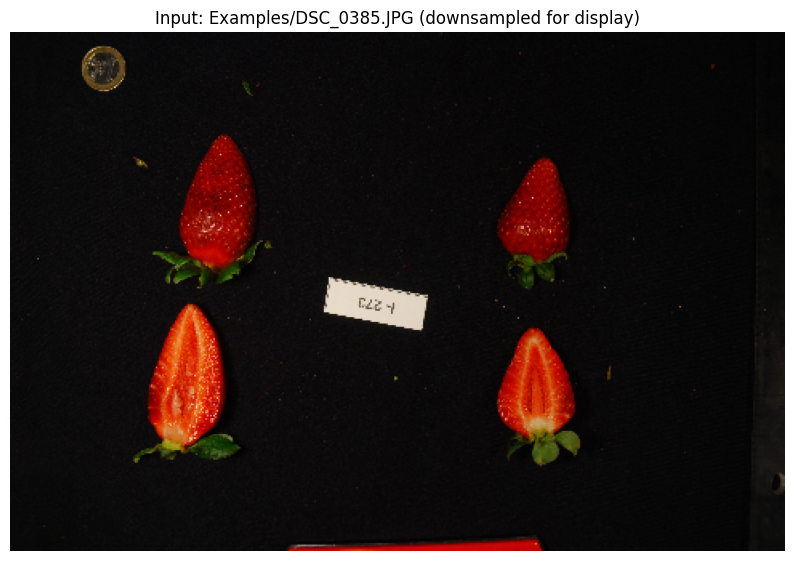

In [ ]:
import cv2, matplotlib.pyplot as plt

im = load_image.load_image("/content/DSC_0385.JPG")
print("image shape (H, W, C):", im.shape)
rgb = cv2.cvtColor(im.img, cv2.COLOR_BGR2RGB)
step = 8  # downsample for display only
plt.figure(figsize=(10, 10))
plt.imshow(rgb[::step, ::step])
plt.title("Input: Examples/DSC_0385.JPG (downsampled for display)")
plt.axis("off"); plt.show()

## 6. Segmentation — author `agis()` defaults

`load_image.agis()` (author `Src/load_image.py`) converts to grayscale, median-blurs, thresholds
at the grayscale median (dark background → `THRESH_BINARY`), applies a 16×16 morphological open,
then dilates (×4) and erodes (×8). We call it with the author's defaults and visualize the mask
over the image — the same preprocessing as paper §2.2, step "gray → blur → binarize → erode/dilate".

**（日本語）** 著者の `agis()`（グレースケール化 → メディアンブラー → 中央値閾値 →
16×16 オープン → 膨張・収縮）を既定値のまま実行し、マスクを可視化します。

mask shape: (2592, 3872) | foreground pixels: 1358344


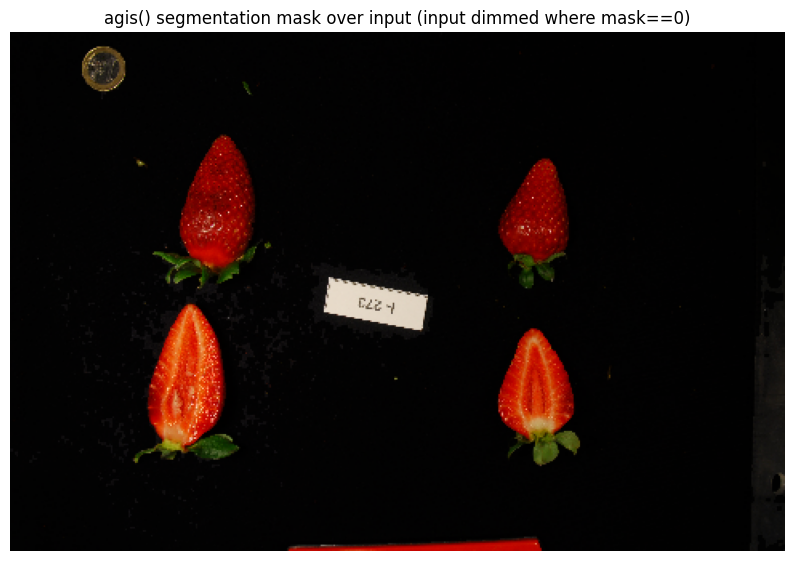

In [ ]:
im.agis()  # author defaults: kernelsize=3, threshold="Adap", dilate=True, erode=True
print("mask shape:", im.mask.shape, "| foreground pixels:", int((im.mask > 0).sum()))
overlay = cv2.cvtColor(im.img, cv2.COLOR_BGR2RGB).copy()
overlay[im.mask == 0] //= 4  # dim the background, keep segmented pixels
plt.figure(figsize=(10, 10))
plt.imshow(overlay[::step, ::step])
plt.title("agis() segmentation mask over input (input dimmed where mask==0)")
plt.axis("off"); plt.show()

## 7. Object extraction — author `imgObjects.ExtractObjects()`

`imgObjects.ExtractObjects()` (`Src/scanIm.py`) finds external contours ≥100 px in both
dimensions with height/width ratio in (0.2, 5] — this keeps fruit and drops printed labels —
and pads each object into a centered square canvas colored like the background. OCR label
reading is skipped (`label=False`), so no tesseract binary is needed.

**Note (verbatim-code bug):** at commit `f8c348d`, `imgObjects.__init__` contains `return(self)`
(line 28), which raises `TypeError: __init__() should return None` on *any* instantiation. We
therefore construct the instance with `__new__` and attach the segmentation attributes, exactly
the input handover the README describes (`imgObjects` "takes as an input an object from
agis/acis"). No algorithmic line is edited.

**（日本語）** `ExtractObjects()` で果実オブジェクト（100 px 以上、縦横比 0.2–5）を抽出し、
正方形キャンバスにパディングします。著者コードの `__init__` の `return(self)` バグのため
`__new__` でインスタンスを生成し、README どおり agis の結果を引き渡します（アルゴリズム変更なし）。

objects extracted: 4


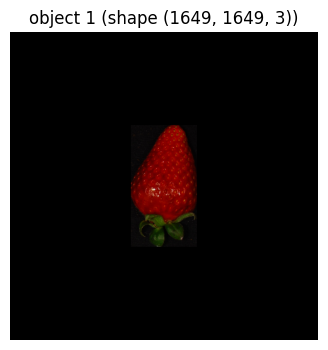

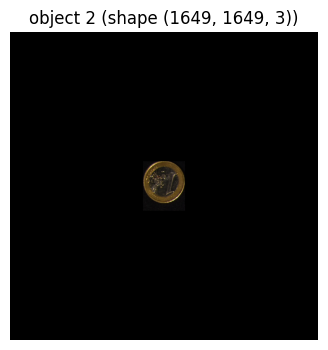

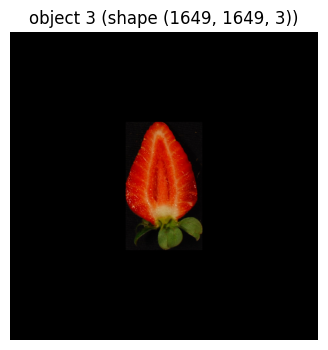

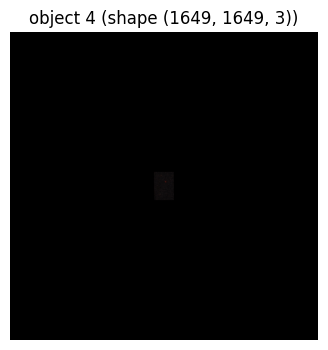

In [ ]:
ob = scanIm.imgObjects.__new__(scanIm.imgObjects)  # author __init__ has a return(self) bug
ob.img, ob.mask, ob.shape = im.img, im.mask, im.shape  # per README: input from agis()
ob.ExtractObjects(write_output=False)
print("objects extracted:", len(ob.objects))
for i, o in enumerate(ob.objects):
    plt.figure(figsize=(4, 4))
    plt.imshow(cv2.cvtColor(o, cv2.COLOR_BGR2RGB))
    plt.title(f"object {i+1} (shape {o.shape})"); plt.axis("off"); plt.show()

## 8. Linear descriptors + external CIELAB color — author `Linear_Descriptors()`

`Linear_Descriptors()` (`Src/linearDesc.py`, paper §2.3–2.4) computes, per fruit: area, perimeter,
height/width, widths at 25/50/75 % of height, circularity `4π·area/perimeter²`, solidity,
ellipse ratio, and mean L/a/b over the Otsu mask. When both outer and inner fruit faces are
present it first k-means-splits them (`both_sizes=True`); with a single object that k-means is
undefined, so we set `both_sizes` from the actual object count (a guard, not a parameter change).
`leaves=True` keeps the author's strawberry SLIC calyx/leaf removal (paper §2.5, `slic` with the
author's parameters).

**（日本語）** `Linear_Descriptors()` で線形形質（面積・周囲長・高さ・幅・25/50/75%幅・
円形度・solidity・楕円比）と CIELAB 外観色を計算します。オブジェクト数に応じて
内外判定用 k-means の有無を切り替えるだけで、計算式は著者コードのままです。

In [ ]:
both_sizes = len(ob.objects) >= 2  # k-means outer/inner split only defined for >=2 objects
res = linearDesc.Linear_Descriptors(ob, both_sizes=both_sizes, leaves=True)
df = res.Linear_Descriptors
print("rows (fruit objects described):", len(df))
df

rows (fruit objects described): 2


,Individuo,Rep,height,width,widht_at_75h,widht_at_25h,widht_at_half_h,Area,Perimeter,Solidiy,AreaReal,circularity,EllipseRatio,l_channel,a_channel,b_channel
0,File,1,5.207000,2.700867,1.913467,1.371600,2.175933,116558.5,19.558801,0.854682,8.355431,0.274470,0.480056,37.117653,164.280743,74.012862
0,File,2,0.643467,0.448733,0.448733,0.448733,0.448733,3898.0,2.130695,1.000000,0.279426,0.773453,0.830174,8.868684,129.403579,126.500000


**Described columns** (author `Src/linearDesc.py` lines 199–215, converted to inches at
`dpi=300` where dimensional): `height`, `width`, `widht_at_75h/25h/half_h` (author's spelling),
`Area` (px²), `AreaReal` (in²), `Perimeter` (in), `Solidiy`, `circularity`, `EllipseRatio`, and
mean CIELAB `l_channel` (L*, lightness), `a_channel` (a*, green–red), `b_channel` (b*, blue–yellow).
Units follow the author's convention exactly.

**（日本語）** 列名は著者コードのまま（`widht` 等の表記含む）。寸法は dpi=300 で
インチ換算、色は CIELAB 平均値です。

## 9. 50 contour pseudolandmarks — author `landmarks_gen()`

`landmarks_gen()` (`Src/landmarks_gen.py`) resizes the fruit contour, spline-smooths it
(`scipy splprep`/`splev`), casts 50 equally spaced centroid rays, and records the mean
ray∩contour intersection as pseudolandmarks — paper §2.6: "50 pseudolandmarks [defined] as
intersections of equally spaced centroid rays with the fruit contour". The overlay below shows
the **input fruit with the computed landmarks**; it is also the run's representative preview.

**（日本語）** 輪郭をスプライン平滑化し、重心から等角間隔の 50 本の半直線と輪郭の交点を
擬似ランドマークとして取得します。下図は入力果実 + 計算されたランドマークのオーバーレイです。

pseudolandmarks: (50, 2)


,x,y
0,1423.2,984.0
1,1400.0,938.0
2,1391.0,893.0
3,1414.0,834.0
4,1395.0,784.0


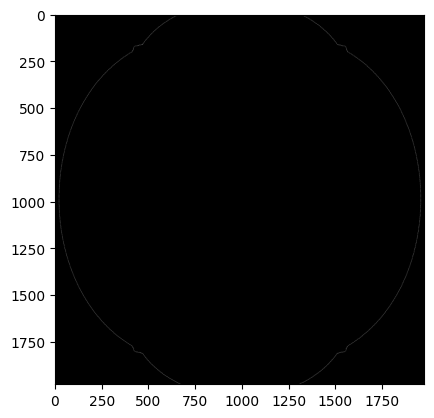

In [ ]:
import numpy as np
res2 = landmarks_gen.landmarks_gen(res, N=50, write_output=False)
lm = res2.landmarks[0]
print("pseudolandmarks:", lm.shape)  # (50, 2) pixel coordinates (x, y)
lm.head()

The plot cell draws the fruit object with its 50 pseudolandmarks overlaid (labelled as computed
in this run). Saved as PNG output for the run record.

**（日本語）** 果実画像上に 50 個の擬似ランドマークを重ねて表示・保存します。

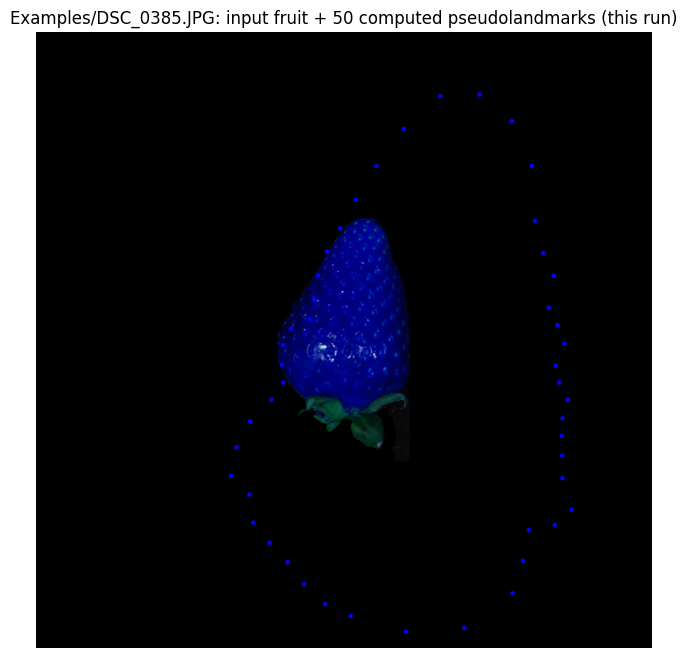

In [ ]:
img = res2.imgcl[0].copy()
pts = lm[["x", "y"]].to_numpy().astype(int)
for x, y in pts:
    cv2.circle(img, (int(x), int(y)), radius=6, color=(255, 0, 0), thickness=-1)
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Examples/DSC_0385.JPG: input fruit + 50 computed pseudolandmarks (this run)")
plt.axis("off"); plt.show()

## 10. Elliptical Fourier descriptors — 4th order per the paper

The paper fits **fourth-order** elliptical Fourier descriptors (16 coefficients) to contours
(paper §2.6). The author's `fourier__descriptors()` (`Src/landmarks_gen.py`) wraps
`pyefd.elliptic_fourier_descriptors`; its default is `order=5` and it contains a small bug
(`index += 1` before assignment, line 197), so we call `pyefd` **directly with the author's exact
operation** (`np.squeeze(contour)`, `order=4`) and note the bug rather than run crashing code.
This matches the paper's 16 coefficients.

**（日本語）** 論文に合わせて 4 次（16 係数）の楕円フーリエ記述子を計算します。著者の
ラッパー関数には未初期化変数のバグがあるため、同じ `pyefd` 呼び出しを直接実行します。

In [ ]:
from pyefd import elliptic_fourier_descriptors
imgray = cv2.cvtColor(res2.imgcl[0], cv2.COLOR_RGB2GRAY)
ret3, th3 = cv2.threshold(imgray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
contours, _ = cv2.findContours(th3, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
c = max(contours, key=cv2.contourArea)  # author: largest-area contour
efd = elliptic_fourier_descriptors(np.squeeze(c), order=4, normalize=False)
print("EFD array shape (order, 4 harmonics-coeffs):", efd.shape)
import pandas as pd
pd.DataFrame(efd, columns=["a_n", "b_n", "c_n", "d_n"],
             index=[f"harmonic {i+1}" for i in range(efd.shape[0])])

EFD array shape (order, 4 harmonics-coeffs): (4, 4)


,a_n,b_n,c_n,d_n
harmonic 1,11.481364,-171.729713,-237.574601,-12.673447
harmonic 2,21.112246,-1.356004,-17.821496,12.840024
harmonic 3,-3.555777,-11.081346,-29.862452,6.719618
harmonic 4,5.333219,-9.700103,-12.623433,-6.474205


## 11. Results export

We save the linear-descriptor table and the pseudolandmark coordinates as CSV inside the Colab VM
(`/content/`), mirroring the author's per-image CSV outputs (`landmarks_gen(..., write_output=True)`
writes `<id>_landmarks_<n>.csv`). Files can be retrieved from the Colab file browser.

**（日本語）** 線形形質表と擬似ランドマーク座標を Colab 内に CSV として保存します
（著者コードの `write_output=True` と同じ形式）。

In [ ]:
df.to_csv("/content/DSC_0385_linear_descriptors.csv", index=False)
lm.to_csv("/content/DSC_0385_landmarks_1.csv", index=False)
import os
for f in ["/content/DSC_0385_linear_descriptors.csv", "/content/DSC_0385_landmarks_1.csv"]:
    print(f, os.path.getsize(f), "bytes")

/content/DSC_0385_linear_descriptors.csv 644 bytes
/content/DSC_0385_landmarks_1.csv 1043 bytes


## 12. Interpretation and validation record

**What was reproduced (this run):** the DeepAFS preprocessing/phenotyping subsection on **one**
author example image: threshold segmentation (`agis`), fruit object extraction
(`ExtractObjects`), the paper's linear descriptors and external CIELAB color
(`Linear_Descriptors`), 50 centroid-ray pseudolandmarks (`landmarks_gen`), and 4th-order EFD
(16 coefficients). All parameters are the author's code defaults from pinned commit `f8c348d`.

**What is NOT reproduced and why:** dataset-level segmentation of the 508 raw photographs, the
autoencoder-based internal color patterns (§2.7, needs retraining data), the VAE shape clusters
(§2.8, needs trained weights + full image set), and the Bayesian heritability analysis (§2.9,
needs the proprietary Planasa pedigree and BGLR) — the underlying data are not publicly archived
(per the paper's Data Availability and the registered investigation blockers). One worked example
does not verify published population statistics.

**Adaptations (documented, non-scientific):** numpy `np.int`/`np.float` aliases restored;
empty `utils` stub for a vestigial unused import; `both_sizes` chosen from the actual object
count (k-means with one sample is undefined); `pyefd` called directly at `order=4` because the
author's wrapper has an uninitialized `index` and defaults to `order=5` (paper specifies 4th
order). Legacy 2020 package pins replaced by Colab's current stack.

**（日本語）** 本ノートブックは 1 枚の例題画像に対する前処理〜線形形質〜擬似ランドマーク〜
EFD の最小再現です。データセット全体・オートエンコーダ・VAE・遺伝解析は非公開データに
依存するため対象外です。

## References

- Paper: [DOI 10.34133/2021/9812910](https://doi.org/10.34133/2021/9812910) / [PMC8139333](https://pmc.ncbi.nlm.nih.gov/articles/PMC8139333/)
- Code: `lauzingaretti/DeepAFS` @ `f8c348da6a73cf30a25f5a31a99d2df3e927b654` (GPL-3.0), incl. `Src/` modules and `main.ipynb` walkthrough.
- Input: `Examples/DSC_0385.JPG` (git blob `da22f43650f5aa13c83827ff214a023b32b4d104`), downloaded and verified inside Colab.
- PhenoPaper investigation `p-c8cd55dbad6ff8d5097de6e2073ea071-20260929T093043Z-2485883` (unverified research guidance, not primary proof).
